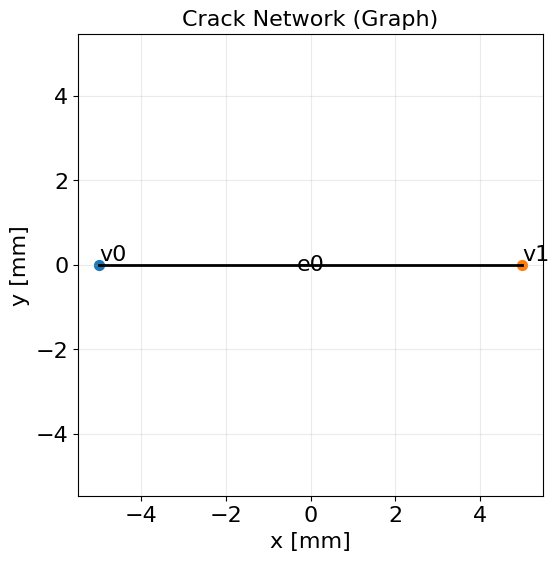

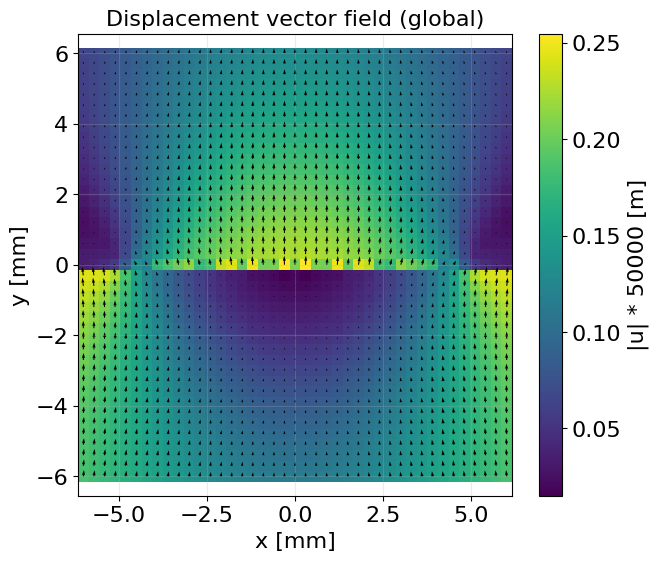

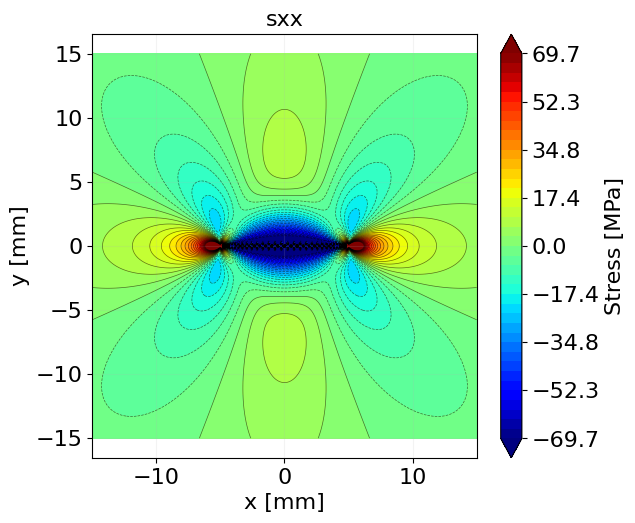

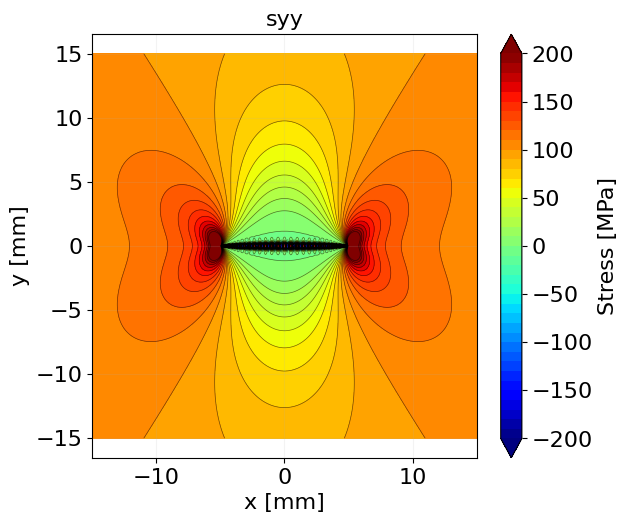

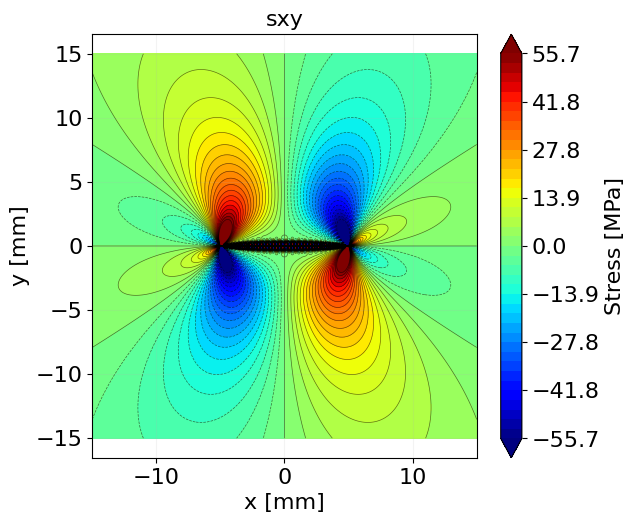

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\SingleHorizontalCrack


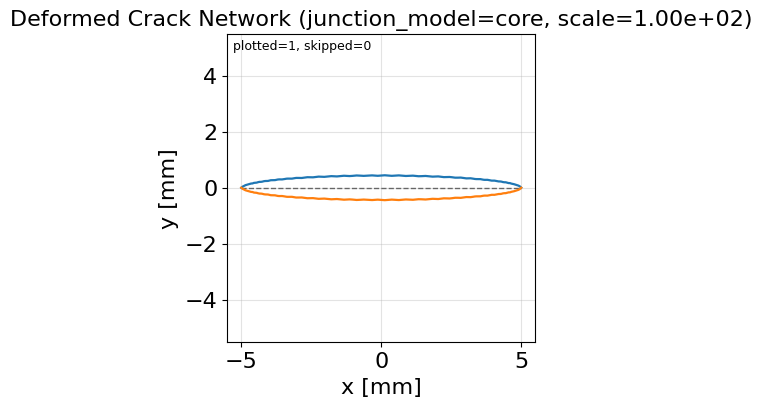

(<Figure size 650x400 with 1 Axes>,
 <Axes: title={'center': 'Deformed Crack Network (junction_model=core, scale=1.00e+02)'}, xlabel='x [mm]', ylabel='y [mm]'>)

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 16,
})

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "SingleHorizontalCrack"
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  0.0*mm],   
    [1,   5.0*mm,  0*mm], 
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    enforce_cod_nonnegative=True,
    cod_tol=1e-10,
    cod_max_iter=25,
)


res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=1e2,
    show_faces=True,
    units="mm",
    cod_smooth_window=5,
    csd_smooth_window=5,
    junction_model="core",
)

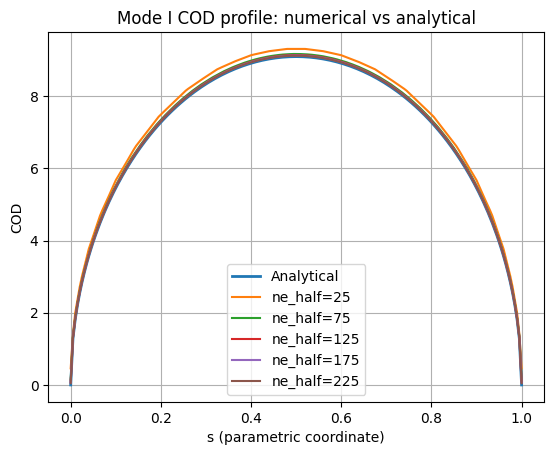

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\COD_validation\cod_overlay_ne_half.png
Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\COD_validation\cod_combined_errors_vs_ne_half.png  |  L2 slope = -0.992  Linf slope = -1.017

All plots saved to: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\COD_validation


In [1]:
# --- COD Validation Cell (fixed calc/network wiring) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *
out_dir = Path(repo_root) / "output" / "COD_validation"
out_dir.mkdir(parents=True, exist_ok=True)
# -------------------------
# Crack/physics metadata (benchmark)
# IMPORTANT: keep 'a' consistent with the geometric half-length used below.
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (meters)

crack_meta = dict(
    a=a_geom,
    sigma=100e6,       # magnitude used in analytical COD (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",    # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Define a single straight crack network (one edge)
# Use a HORIZONTAL crack for Mode I under sigma_yy tension.
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],   # [id, x, y]
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([
    [0, 1],              # edge from v0 -> v1
], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=("stress" in crack_meta["plane"].lower()))

# Remote loading: uniform tension in y gives Mode I for a horizontal crack
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)

# IMPORTANT:
#   - "network" is the geometry
#   - "calc" is the solver object that HAS calc.network, calc.material, calc.applied
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# COD solver hook for validation_cod.run_cod_sweep
# -------------------------
def run_solver_cod(knobs, crack_meta):
    """
    Return CODProfile(s, COD) for one edge using panel-midpoint reconstruction.
    COD is stored in MICRONS for plotting convenience.
    """
    sol = calc.solve(**knobs)

    # DCEResultsNetworkV4 expects (calc, sol), not (network, sol)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x = np.asarray(x, float).reshape(-1)
    COD = np.asarray(COD, float).reshape(-1) * 1e6  # Convert meters to microns
    CSD = np.asarray(CSD, float).reshape(-1)
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=COD,  # Now in microns
        meta=dict(x=x, CSD=CSD, **extra),
    )

# -------------------------
# Analytical COD: infinite plate, straight central crack under uniform tension
# delta(x) = (4*sigma/E')*sqrt(a^2 - x^2)
# Returns COD in MICRONS
# -------------------------
def analytical_cod(s, crack_meta):
    a = float(crack_meta["a"])
    sigma = float(crack_meta["sigma"])
    E = float(crack_meta["E"])
    nu = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    cod_m = (4.0 * sigma / Eprime) * np.sqrt(np.maximum(a * a - x * x, 0.0))
    return cod_m * 1e6  # Convert meters to microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(25, 230, 25))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=ne,
        crack_mode="full",
        representation="cheb_quad",   # or "panel", "singular", "cheb_quad"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run COD sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_cod,
    analytical_cod=analytical_cod,
    s_sample=201,
)

# -------------------------
# Plot and save figures
# -------------------------

# Figure 1: COD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode I COD profile: numerical vs analytical",
)
if result1 is not None:
    fig1, ax1 = result1  # Unpack the tuple
    filepath1 = out_dir / "cod_overlay_ne_half.png"

    # Update y-axis label to reflect microns
    ax1.set_ylabel(r"COD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches="tight")
    print(f"Saved: {filepath1}")
    plt.close(fig1)

# Figure 2: Combined L2 and Linf COD errors on log-log axes
# (algebraic convergence e ~ N^{-p} shows as a straight line of slope -p)
fig2, ax2 = plt.subplots(figsize=(8, 6))

ne_values = []
l2_errors = []
linf_errors = []

for item in sweep.results:
    ne_values.append(item.knobs["ne_half"])
    l2_errors.append(item.l2_rel_pct)
    linf_errors.append(item.linf_rel_pct)

ne_arr = np.asarray(ne_values, dtype=float)
l2_arr = np.asarray(l2_errors, dtype=float)
linf_arr = np.asarray(linf_errors, dtype=float)

# Fit slope p in log-log: log(e) = log(C) - p * log(N)
def _fit_slope(x, y):
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if int(mask.sum()) < 2:
        return np.nan, np.nan
    lx = np.log(x[mask]); ly = np.log(y[mask])
    p, c = np.polyfit(lx, ly, 1)
    return float(p), float(c)

p_l2, c_l2 = _fit_slope(ne_arr, l2_arr)
p_linf, c_linf = _fit_slope(ne_arr, linf_arr)

ax2.loglog(ne_arr, l2_arr, marker="o", linewidth=2,
           label=r"$L_2$ relative error  (slope $\approx %.2f$)" % p_l2)
ax2.loglog(ne_arr, linf_arr, marker="s", linewidth=2,
           label=r"$L_\infty$ relative error  (slope $\approx %.2f$)" % p_linf)

# Reference slope guides (-1 and -2) anchored to the L2 curve at ne_arr[0]
if np.isfinite(p_l2):
    n_ref = np.array([ne_arr.min(), ne_arr.max()], dtype=float)
    e0 = l2_arr[0]
    n0 = ne_arr[0]
    e_ref1 = e0 * (n_ref / n0) ** (-1.0)
    e_ref2 = e0 * (n_ref / n0) ** (-2.0)
    ax2.loglog(n_ref, e_ref1, ls="--", color="gray", lw=1,
               label=r"reference slope $-1$")
    ax2.loglog(n_ref, e_ref2, ls=":", color="gray", lw=1,
               label=r"reference slope $-2$")

ax2.set_xlabel(r"$N^{e}_{\mathrm{half}}$", fontsize=16)
ax2.set_ylabel("Relative error (%)", fontsize=16)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(fontsize=16)
ax2.tick_params(axis="both", which="major", labelsize=16)

filepath2 = out_dir / "cod_combined_errors_vs_ne_half.png"
fig2.savefig(filepath2, dpi=300, bbox_inches="tight")
print(f"Saved: {filepath2}  |  L2 slope = {p_l2:.3f}  Linf slope = {p_linf:.3f}")
plt.close(fig2)

print(f"\nAll plots saved to: {out_dir}")


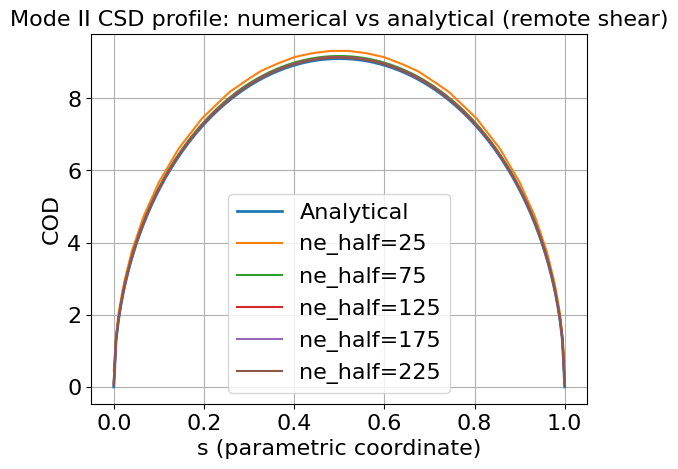

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\CSD_validation_ModeII\csd_overlay_ne_half.png
Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\CSD_validation_ModeII\csd_combined_errors_vs_ne_half.png

All plots saved to: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\CSD_validation_ModeII


In [3]:
#### VALIDATION OF A MODE II CRACK UNDER SHEAR LOADING (CSD)

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "CSD_validation_ModeII"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Crack/physics metadata (benchmark)
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm  # half-length (m)
tau0   = 100e6      # remote shear (Pa)

crack_meta = dict(
    a=a_geom,
    tau=tau0,         # remote shear magnitude (Pa)
    E=200e9,
    nu=0.30,
    plane="strain",   # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Geometry: single horizontal crack (-a,0) -> (+a,0)
# Mode II: apply uniform remote shear sigma_xy = tau
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(
    E=crack_meta["E"],
    nu=crack_meta["nu"],
    plane_stress=("stress" in crack_meta["plane"].lower()),
)

applied = AppliedStress(
    sigma_xx=0.0,
    sigma_yy=0.0,
    sigma_xy=+crack_meta["tau"],
)

calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Solver hook: return CSD profile using the CODProfile container
# -------------------------
def run_solver_csd(knobs, crack_meta):
    """
    Returns CODProfile(s, csd_um) for one edge.
    We store CSD (sliding displacement jump) in the 'cod' field for reuse of plotting utilities.
    """
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    x   = np.asarray(x, float).reshape(-1)
    CSD = np.asarray(CSD, float).reshape(-1) * 1e6  # meters -> microns
    extra = dict(extra) if isinstance(extra, dict) else {}

    a_edge = float(extra.get("a_edge", np.max(np.abs(x))))
    s = (x + a_edge) / (2.0 * a_edge)  # map x in [-a_edge, a_edge] -> s in [0,1]

    return CODProfile(
        s=s,
        cod=CSD,  # store CSD in microns
        meta=dict(x=x, **extra),
    )

# -------------------------
# Analytical CSD (Mode II) for infinite plate, central crack under remote shear tau
# delta_t(x) = (4*tau/E') * sqrt(a^2 - x^2)
# Returns CSD in MICRONS.
# -------------------------
def analytical_csd(s, crack_meta):
    a   = float(crack_meta["a"])
    tau = float(crack_meta["tau"])
    E   = float(crack_meta["E"])
    nu  = float(crack_meta["nu"])
    plane = str(crack_meta.get("plane", "strain")).lower()
    Eprime = E / (1.0 - nu**2) if "strain" in plane else E

    s = np.asarray(s, float)
    x = (2.0 * s - 1.0) * a
    csd_m = (4.0 * tau / Eprime) * np.sqrt(np.maximum(a*a - x*x, 0.0))
    return csd_m * 1e6  # meters -> microns

# -------------------------
# Knob sweep
# -------------------------
ne_half_list = list(range(25, 230, 25))

knob_sweep = []
for ne in ne_half_list:
    knob_sweep.append(dict(
        ne_half=int(ne),
        crack_mode="full",              # set "half" if validating half-crack formulation
        representation="cheb_quad",     # "panel", "singular", "cheb_quad", "cheb_spectral"
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    ))

# -------------------------
# Run sweep
# -------------------------
sweep = run_cod_sweep(
    crack_meta=crack_meta,
    knob_sweep=knob_sweep,
    run_solver=run_solver_csd,
    analytical_cod=analytical_csd,   # reuse API; returns CSD
    s_sample=201,
)

# -------------------------
# Plot and save figures
# -------------------------

# Figure 1: CSD overlay
result1 = plot_cod_overlay(
    sweep,
    knob_label_keys=("ne_half",),
    max_curves=5,
    title="Mode II CSD profile: numerical vs analytical (remote shear)",
)
if result1 is not None:
    fig1, ax1 = result1
    filepath1 = out_dir / "csd_overlay_ne_half.png"
    ax1.set_ylabel(r"CSD ($\mu$m)")
    ax1.set_xlabel("Normalized position s")
    ax1.grid(True)
    ax1.legend()
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    plt.close(fig1)

# Figure 2: Combined L2 and Linf errors on same plot
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Extract error data from sweep.results
ne_values = []
l2_errors = []
linf_errors = []

for item in sweep.results:  # Access .results attribute
    ne_values.append(item.knobs['ne_half'])  # item.knobs is a dict
    l2_errors.append(item.l2_rel_pct)        # Use attribute access
    linf_errors.append(item.linf_rel_pct)    # Use attribute access

# Plot both error metrics
ax2.plot(ne_values, l2_errors, marker='o', label=r'$L_2$ Error', linewidth=2)
ax2.plot(ne_values, linf_errors, marker='s', label=r'$L_\infty$ Error', linewidth=2)

ax2.set_xlabel('ne_half', fontsize=16)
ax2.set_ylabel('Relative Error (%)', fontsize=16)
ax2.set_title('Mode II CSD Convergence: Error vs Discretization', fontsize=16)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=16)

filepath2 = out_dir / "csd_combined_errors_vs_ne_half.png"
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")
plt.close(fig2)

print(f"\nAll plots saved to: {out_dir}")

Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\SIF-validation\sif_error_vs_ne_half_ncol12_nsig16_linear.png
Saved: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\SIF-validation\sif_error_vs_ne_half_ncol12_nsig16_log.png


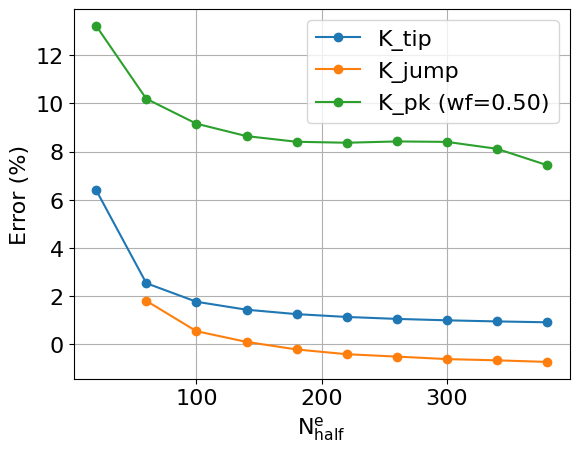

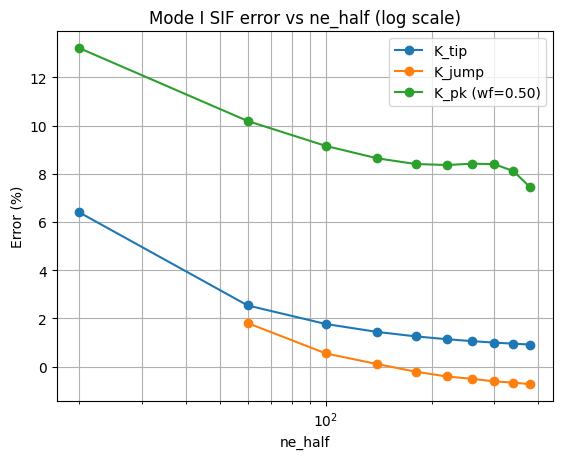

In [3]:
# --- SIF Validation Cell (4 estimators; PK uses window_frac + normal_offset_frac sweep) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "SIF-validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Benchmark: straight crack, Mode I
# -------------------------
mm = 1e-3
a_geom = 5.0 * mm
sigma0 = 100e6

crack_meta = dict(
    a=a_geom,
    sigma=sigma0,
    E=200e9,
    nu=0.30,
    plane="strain",  # "strain" or "stress"
    edge_index=0,
)

# -------------------------
# Build a single-edge network
# -------------------------
vertices = np.array([
    [0, -a_geom, 0.0],
    [1, +a_geom, 0.0],
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

network = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

plane_stress = ("stress" in str(crack_meta["plane"]).lower())
material = Material(E=crack_meta["E"], nu=crack_meta["nu"], plane_stress=plane_stress)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=+crack_meta["sigma"], sigma_xy=0.0)
calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

# -------------------------
# Analytical SIF
# -------------------------
def KI_analytic(a, sigma):
    return float(sigma * np.sqrt(np.pi * a))

# -------------------------
# Run one solve and return the 3 "good" estimators + PK (with tunables)
# -------------------------
def solve_and_estimate(ne_half: int, *, window_frac: float, normal_offset_frac: float, representation: str = "cheb_quad"):
    knobs = dict(
        ne_half=int(ne_half),
        crack_mode="half",
        representation=str(representation),
        node_distribution="tip_dense",
        nq_col=12,
        nq_stress=16,
        ridge=1e-10,
        r0_factor=1e-3,
        solver_option="parametrized_crack",
        parametrization="polyline",
    )
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    edge_index = int(crack_meta.get("edge_index", 0))

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=True)
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", float(crack_meta["a"])))

    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    mu = E / (2.0 * (1.0 + nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa  = (3.0 - nu) / (1.0 + nu) if plane_stress_local else (3.0 - 4.0 * nu)
    Eprime = E if plane_stress_local else (E / (1.0 - nu**2))

    # Tip-fit
    KI_tip, KII_tip, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit, mu=mu, kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.80,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )

    # Jump
    KI_jump, KII_jump = estimate_KI_KII_from_jumps_near_tip(
        x=x, COD=COD, CSD=CSD,
        a=a_fit,
        Eprime=Eprime,
        side="right",
        frac_window=0.08,
    )

    # PK (Mode I: KI = sqrt(E' * J1))
    pk = PKProcessor(res)
    F = pk.F_PK_window(
        edge_index=edge_index,
        at="end",
        exclude_self=True,
        window_panels=0,               # force frac-mode
        window_frac=float(window_frac),
        min_panels=12,
        normal_offset_frac=float(normal_offset_frac),
    )
    if F is None:
        KI_pk = float("nan")
        J1 = float("nan")
    else:
        # local tangent from reconstructor
        _, _, _, extra2 = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=False)
        extra2 = dict(extra2)
        ex = np.asarray(extra2["ex"], float).reshape(2,)
        J1 = float(np.dot(np.asarray(F, float).reshape(2,), ex))
        KI_pk = float(np.sqrt(max(E * J1, 0.0)))

    # Mode I analytic
    KI_ref = KI_analytic(a_fit, float(crack_meta["sigma"]))

    return dict(
        ne_half=int(ne_half),
        a_fit=a_fit,
        Eprime=Eprime,
        KI_ref=KI_ref,
        KI_tip=float(KI_tip),
        KI_jump=float(KI_jump),
        KI_pk=float(KI_pk),
        J1=float(J1),
    )

# -------------------------
# Sweep ne_half with a small grid of PK tunables and plot
# -------------------------
ne_half_list = list(range(20, 420, 40))

# Choose a few combinations (3–5) to avoid crowding
pk_variants = [
    # dict(window_frac=0.20, normal_offset_frac=0.0,    label="wf=0.20, off=0"),
    dict(window_frac=0.50, normal_offset_frac=5e-6, label="wf=0.50"),
]

# Precompute baseline tip/jump once per ne_half (reuse first variant result)
baseline = {}
pk_results = {v["label"]: [] for v in pk_variants}

for ne in ne_half_list:
    r0 = solve_and_estimate(ne, window_frac=pk_variants[0]["window_frac"], normal_offset_frac=pk_variants[0]["normal_offset_frac"])
    baseline[ne] = dict(KI_ref=r0["KI_ref"], KI_tip=r0["KI_tip"], KI_jump=r0["KI_jump"])

    for v in pk_variants:
        r = solve_and_estimate(ne, window_frac=v["window_frac"], normal_offset_frac=v["normal_offset_frac"])
        pk_results[v["label"]].append(r)

# -------------------------
# Plot error vs ne_half
# -------------------------
def err_pct(K, Kref):
    return 100.0 * (K - Kref) / Kref

# First figure: linear x-axis
fig1, ax1 = plt.subplots()
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax1.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax1.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax1.set_xlabel(r"$N^{e}_{\mathrm{half}}$", fontsize=16)
ax1.set_ylabel("Error (%)", fontsize=16)
ax1.grid(True)
ax1.legend(fontsize=16)
ax1.tick_params(axis="both", which="major", labelsize=16)
filepath1 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_linear.png'
fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath1}")

# Second figure: log x-axis
fig2, ax2 = plt.subplots()
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_tip"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_tip")
ax2.plot(ne_half_list, [err_pct(baseline[ne]["KI_jump"], baseline[ne]["KI_ref"]) for ne in ne_half_list],
        marker="o", label="K_jump")
# PK variants
for lab, arr in pk_results.items():
    ax2.plot(ne_half_list, [err_pct(a["KI_pk"], a["KI_ref"]) for a in arr], marker="o", label=f"K_pk ({lab})")
ax2.set_xlabel("ne_half")
ax2.set_ylabel("Error (%)")
ax2.set_title("Mode I SIF error vs ne_half (log scale)")
ax2.set_xscale('log')
ax2.grid(True, which='both')
ax2.legend()
filepath2 = out_dir / 'sif_error_vs_ne_half_ncol12_nsig16_log.png'
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")

plt.show()



Solving ne_half = 20

Solving ne_half = 40

Solving ne_half = 60

Solving ne_half = 120


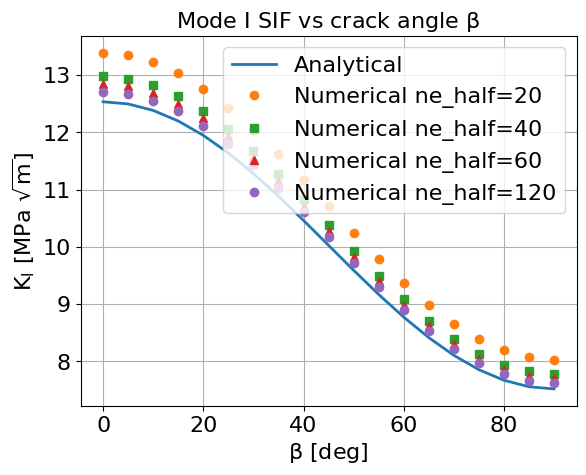

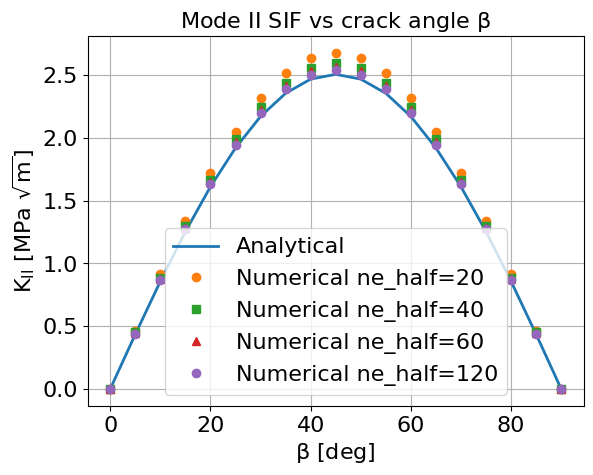


Saved plots to: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\MixedMode_SIF_validation


In [5]:
# --- Mixed-Mode SIF validation: inclined crack under biaxial loading (plots like Fig. B/C) ---
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- repo root on sys.path (one level above notebooks/)
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *   
out_dir = Path(repo_root) / "output" / "MixedMode_SIF_validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem definition (match the paper figure)
# Crack length = 2a, inclined by beta from loading axis.
# Analytical (Rooke & Cartwright):
#   KI  = sqrt(pi a) ( σ22 cos^2β + σ11 sin^2β )
#   KII = sqrt(pi a) ( σ22 - σ11 ) sinβ cosβ
# -------------------------
mm = 1e-3
a = 5.0 * mm                  # half-length (m)
sig11 = 60e6                  # Pa  (σ11)
sig22 = 100e6                 # Pa  (σ22)
plane = "strain"              # "strain" or "stress"
edge_index = 0

# Sweep β in degrees (0..90)
beta_deg = np.linspace(0.0, 90.0, 19)
beta_rad = np.deg2rad(beta_deg)

# Numerical resolutions
ne_list = [20, 40, 60, 120]

# Solver knobs (common)
base_knobs = dict(
    crack_mode="full",
    representation="cheb_quad",     # you can switch to "cheb_spectral" once stable
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    parametrization="polyline",
)

# -------------------------
# Helpers
# -------------------------
def analytical_K(beta):
    """Return (KI, KII) for beta (radians)."""
    KI  = np.sqrt(np.pi * a) * (sig22 * (np.cos(beta)**2) + sig11 * (np.sin(beta)**2))
    KII = np.sqrt(np.pi * a) * ((sig22 - sig11) * np.sin(beta) * np.cos(beta))
    return KI, KII

def crack_endpoints(beta):
    """Horizontal crack rotated by beta about origin."""
    c = np.cos(beta); s = np.sin(beta)
    p0 = np.array([-a, 0.0])
    p1 = np.array([+a, 0.0])
    R = np.array([[c, -s],[s, c]])
    q0 = R @ p0
    q1 = R @ p1
    return q0, q1

def solve_K_for_beta(beta, ne_half):
    """Solve for a given beta and ne_half; return (KI_tip, KII_tip)."""
    q0, q1 = crack_endpoints(beta)

    vertices = np.array([
        [0, q0[0], q0[1]],
        [1, q1[0], q1[1]],
    ], dtype=float)

    connectivity = np.array([[0, 1]], dtype=int)

    network = CrackNetworkV4.from_vertices_connectivity(
        vertices=vertices,
        connectivity=connectivity,
        Nv_max=3,
        validate=True,
    )

    material = Material(
        E=200e9,
        nu=0.30,
        plane_stress=("stress" in plane.lower()),
    )

    applied = AppliedStress(
        sigma_xx=float(sig11),
        sigma_yy=float(sig22),
        sigma_xy=0.0,
    )

    calc = DCENetworkStaticV4(material=material, network=network, applied=applied)

    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    extra = dict(extra) if isinstance(extra, dict) else {}
    a_fit = float(extra.get("a_edge", a))

    # elastic constants for sif_from_cod_fit
    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    mu = E / (2.0 * (1.0 + nu))
    plane_stress_local = bool(getattr(res.calc.material, "plane_stress", False))
    kappa = (3.0 - nu) / (1.0 + nu) if plane_stress_local else (3.0 - 4.0 * nu)

    KI, KII, meta = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_fit,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.60,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )
    return float(KI), float(KII)

# -------------------------
# Compute curves
# -------------------------
KI_ana = np.zeros_like(beta_deg, float)
KII_ana = np.zeros_like(beta_deg, float)
for i, b in enumerate(beta_rad):
    KI_ana[i], KII_ana[i] = analytical_K(b)

KI_num = {ne: np.zeros_like(beta_deg, float) for ne in ne_list}
KII_num = {ne: np.zeros_like(beta_deg, float) for ne in ne_list}

for ne in ne_list:
    print(f"\nSolving ne_half = {ne}")
    for i, b in enumerate(beta_rad):
        KI, KII = solve_K_for_beta(b, ne_half=ne)
        KI_num[ne][i] = KI
        KII_num[ne][i] = KII

# Convert to MPa*sqrt(m) for plotting
scale = 1e-6  # Pa*sqrt(m) -> MPa*sqrt(m)
KI_ana_p = KI_ana * scale
KII_ana_p = KII_ana * scale
KI_num_p = {ne: KI_num[ne] * scale for ne in ne_list}
KII_num_p = {ne: KII_num[ne] * scale for ne in ne_list}

# -------------------------
# Plot (B): KI vs beta
# -------------------------
figB, axB = plt.subplots()
axB.plot(beta_deg, KI_ana_p, label="Analytical", linewidth=2)
markers = {20:"o", 40:"s", 60:"^"}
for ne in ne_list:
    axB.plot(beta_deg, KI_num_p[ne], marker=markers.get(ne,"o"), linestyle="None", label=f"Numerical ne_half={ne}")
axB.set_xlabel(r"$\beta$ [deg]")
axB.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
axB.set_title(r"Mode I SIF vs crack angle $\beta$")
axB.grid(True)
axB.legend()
figB.savefig(out_dir / "KI_vs_beta.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------
# Plot (C): KII vs beta
# -------------------------
figC, axC = plt.subplots()
axC.plot(beta_deg, KII_ana_p, label="Analytical", linewidth=2)
for ne in ne_list:
    axC.plot(beta_deg, KII_num_p[ne], marker=markers.get(ne,"o"), linestyle="None", label=f"Numerical ne_half={ne}")
axC.set_xlabel(r"$\beta$ [deg]")
axC.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
axC.set_title(r"Mode II SIF vs crack angle $\beta$")
axC.grid(True)
axC.legend()
figC.savefig(out_dir / "KII_vs_beta.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved plots to: {out_dir}")


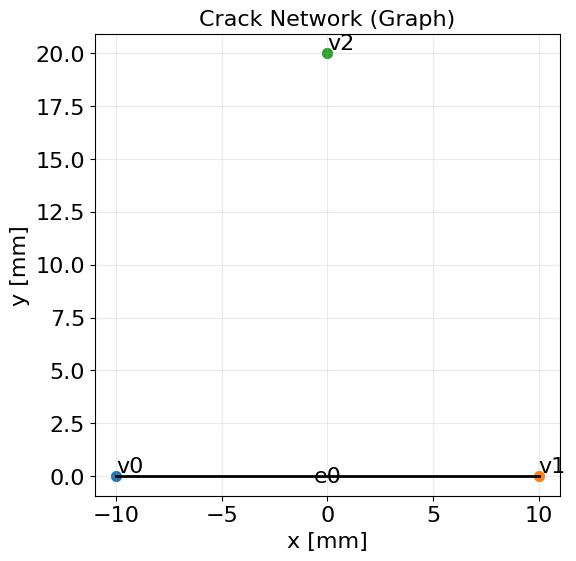

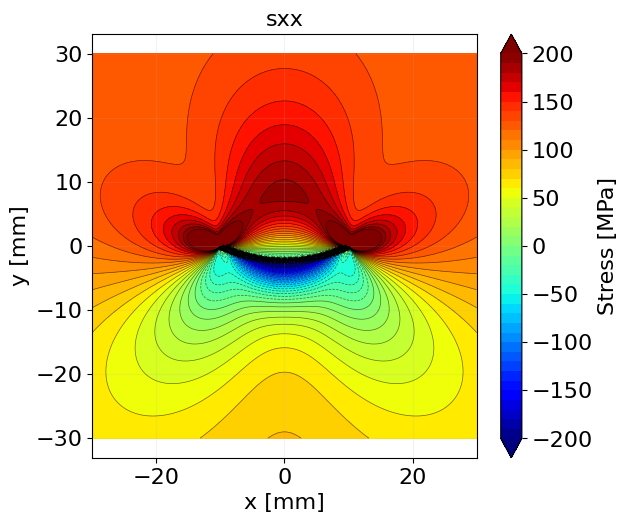

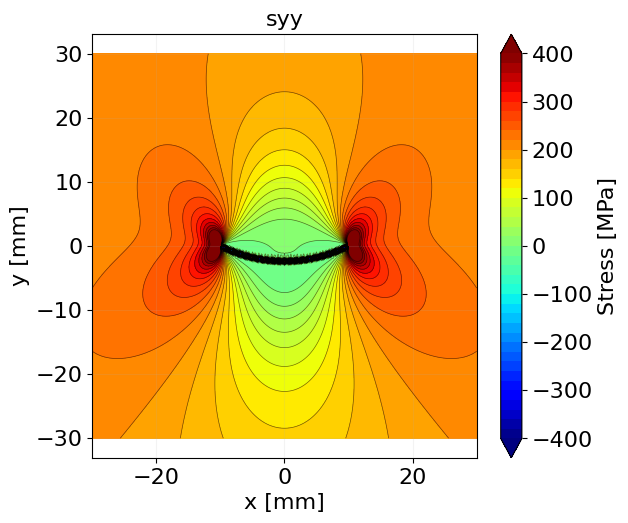

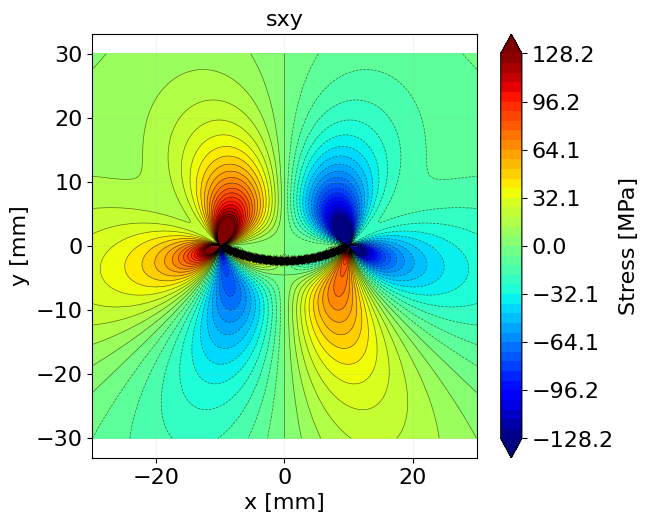

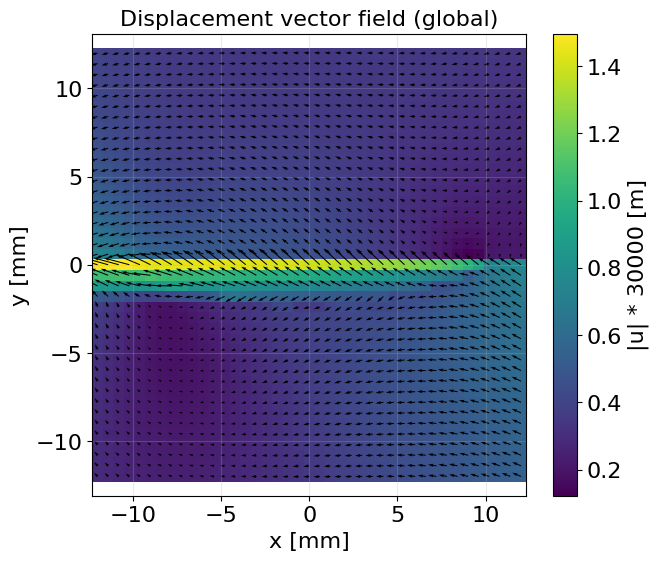

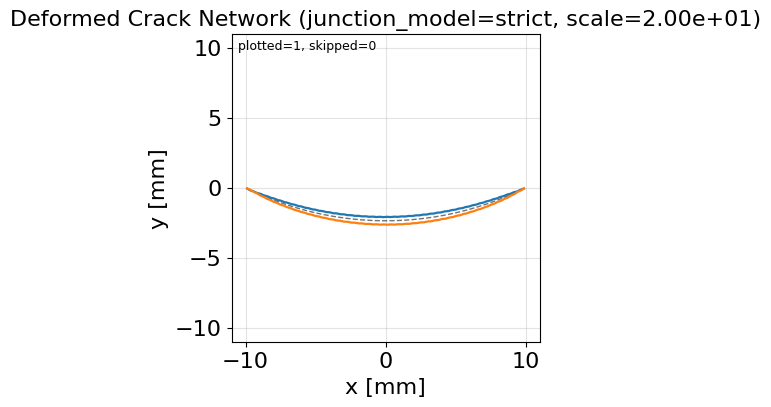

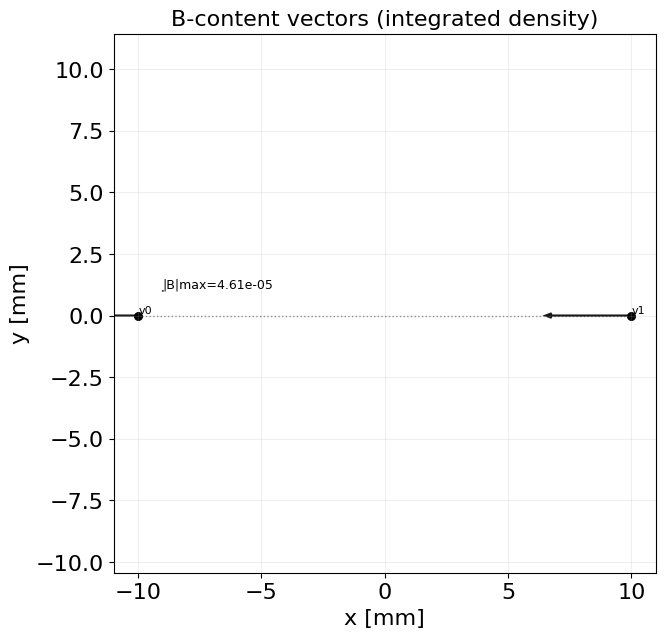

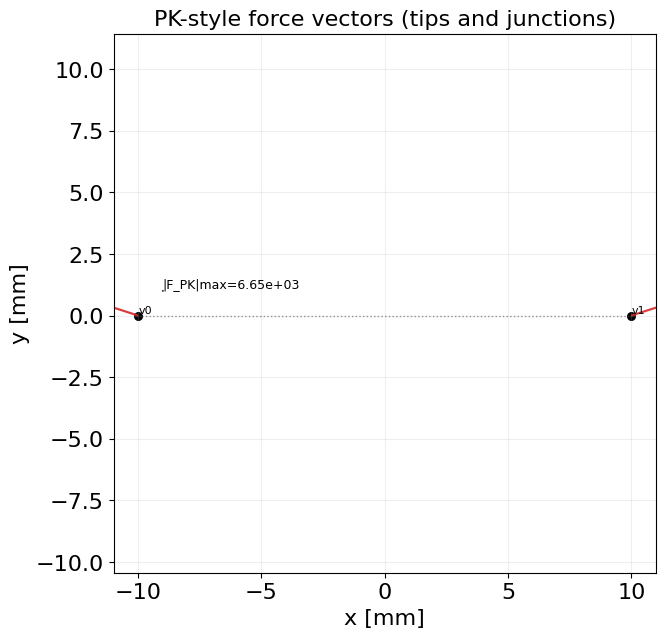

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VCM_3_3\output\ArcField_Results


In [6]:
import os, sys
from pathlib import Path

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# --- Preamble re-exports
from preamble import *   
out_dir = Path(repo_root) / "output" / "ArcField_Results"
out_dir.mkdir(parents=True, exist_ok=True)


# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
a = 10.0 * mm  # crack half-length
alpha_deg = 30.0  # half arc angle in degrees
R = a / np.sin(np.deg2rad(alpha_deg))

V = np.array([
    [0, -a,    0.0],     # endpoint (node)
    [1, a,  0.0],     # endpoint (node)
    [2,  0*mm,  R],    # center (control) 
], float)

E = np.array([
    [0, 1],  
], int)


net = CrackNetworkV4.from_vertices_connectivity(
    vertices=V,
    connectivity=E,
    Nv_max=4,
    validate=True,
    edge_kinds=["arc"],      # one per edge in E, same order
    edge_ctrl_vids=[(2,)],           # one per edge; only arc gets a center
    vertex_roles={2: "control"},
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100.0e6, sigma_yy=200.0e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(ne_half=40, parametrization="polyline", 
                  crack_mode="half",nq_col=12, nq_stress=16, junction_model="strict")
res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=3e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=2e1,
    show_faces=True,
    units="mm",
    junction_model="strict",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)


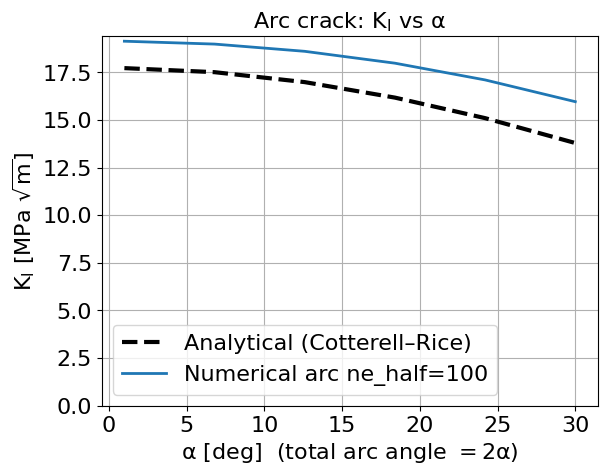

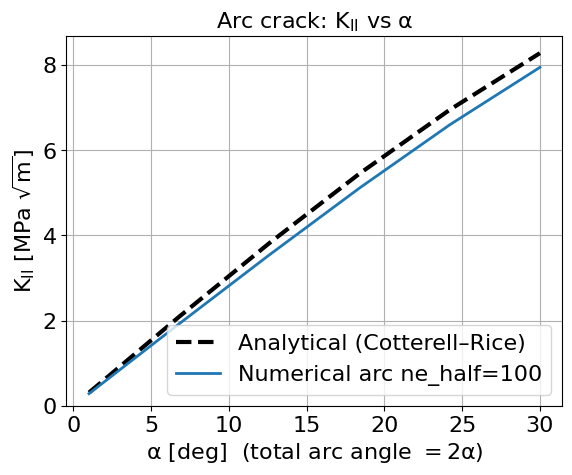

In [7]:
# ============================================================
# Cotterell–Rice (IJF 1980) validation for circular arc crack
# ============================================================

import os, sys
from pathlib import Path

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# --- Preamble re-exports
from preamble import *   
out_dir = Path(repo_root) / "output" / "Arc_CotterellRice_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm     # HALF chord length
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

# alpha = half-angle; total arc angle = 2*alpha
alpha_deg = np.linspace(1.0, 30.0, 6)
alpha = np.deg2rad(alpha_deg)

# solver knobs
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)
# -------------------------
# Arc geometry (TRUE circle center)
# -------------------------
def arc_network(alpha):
    R = a_chord / np.sin(alpha)
    y_c = R * np.cos(alpha)     # TRUE center

    V = np.array([
        [0, -a_chord, 0.0],
        [1,  a_chord, 0.0],
        [2,  0.0,     y_c],     # CONTROL = CENTER
    ], float)

    E = np.array([[0, 1]], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=E,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

# -------------------------
# Solver wrapper
# -------------------------
def solve_K(net, ne_half):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane))
    applied  = AppliedStress(sig_xx, sig_yy, sig_xy)

    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    a_arc = float(extra["a_edge"])  # HALF ARC LENGTH

    mu = E / (2.0 * (1.0 + nu))
    kappa = (3.0 - 4.0 * nu)

    KI, KII, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_arc,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.2,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )

    return float(KI), float(KII), a_arc

# ============================================================
# Run: ARC geometry, ne_half = 80
# ============================================================
ne_half = 100
scale = 1e-6

KI_num = []
KII_num = []
KI_ana = []
KII_ana = []

for al in alpha:
    R = a_chord / np.sin(al)
    a_arc = R * al

    KIa, KIIa = cotterell_rice_K(al, a_chord, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)

    net = arc_network(al)
    KIn, KIIn, _ = solve_K(net, ne_half)
    KI_rn, KII_rn = rotate_sifs(KIn, KIIn, -2*al)

    KI_num.append(KI_rn)
    KII_num.append(KII_rn)
    
KI_ana = np.array(KI_ana)
KII_ana = np.array(KII_ana)
KI_num = np.array(KI_num)
KII_num =-np.array(KII_num)

# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax1.plot(alpha_deg, KI_num*scale, lw=2, label=f"Numerical arc ne_half={ne_half}")
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title("Arc crack: $K_I$ vs $\\alpha$")
ax1.grid(True); ax1.legend()
ax1.set_ylim(bottom=0)
fig1.savefig(out_dir / "KI_vs_alpha_1term_ne80.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax2.plot(alpha_deg,KII_num*scale, lw=2, label=f"Numerical arc ne_half={ne_half}")
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title("Arc crack: $K_{II}$ vs $\\alpha$")
ax2.grid(True); ax2.legend()
ax2.set_ylim(bottom=0)
fig2.savefig(out_dir / "KII_vs_alpha_1term_ne80.png", dpi=300, bbox_inches="tight")
plt.show()



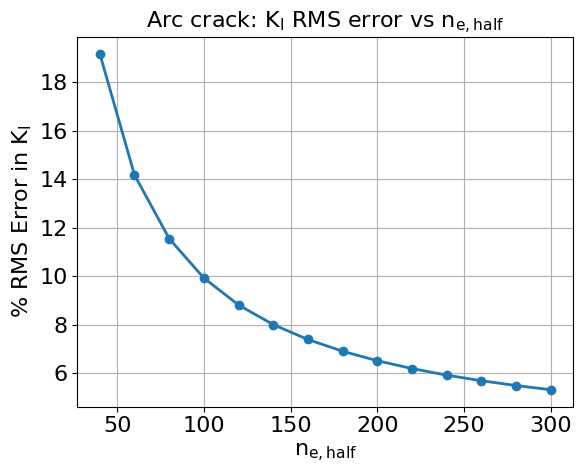

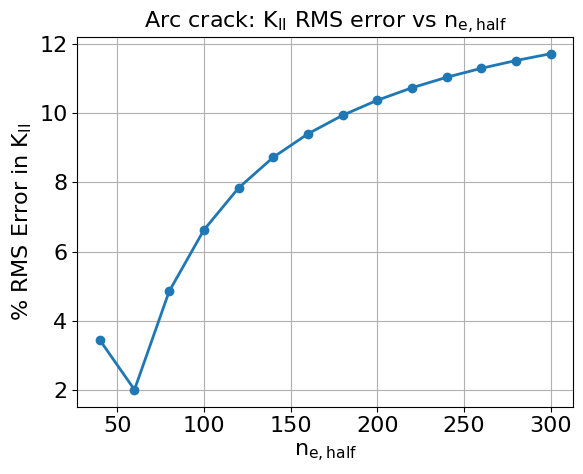

In [8]:
# ============================================================
# Cotterell–Rice (IJF 1980) validation for circular arc crack
# Sweep ne_half and plot L2 error norms in K_I and K_II
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *
out_dir = Path(repo_root) / "output" / "Arc_CotterellRice_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm     # HALF chord length
E = 200e9
nu = 0.30
plane = "strain"
edge_index = 0

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

# alpha = half-angle; total arc angle = 2*alpha
alpha_deg = np.linspace(1.0, 30.0, 6)
alpha = np.deg2rad(alpha_deg)

# solver knobs
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)

# -------------------------
# Arc geometry (TRUE circle center)
# -------------------------
def arc_network(alpha):
    R = a_chord / np.sin(alpha)
    y_c = R * np.cos(alpha)     # TRUE center

    V = np.array([
        [0, -a_chord, 0.0],
        [1,  a_chord, 0.0],
        [2,  0.0,     y_c],     # CONTROL = CENTER
    ], float)

    Econn = np.array([[0, 1]], int)

    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V,
        connectivity=Econn,
        Nv_max=4,
        validate=True,
        edge_kinds=["arc"],
        edge_ctrl_vids=[(2,)],
        vertex_roles={2: "control"},
    )

# -------------------------
# Solver wrapper
# -------------------------
def solve_K(net, ne_half):
    material = Material(E=E, nu=nu, plane_stress=("stress" in plane))
    applied  = AppliedStress(sig_xx, sig_yy, sig_xy)

    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = int(ne_half)

    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)

    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )

    a_arc = float(extra["a_edge"])  # HALF ARC LENGTH

    mu = E / (2.0 * (1.0 + nu))
    kappa = (3.0 - 4.0 * nu) if ("strain" in plane.lower()) else (3.0 - nu) / (1.0 + nu)

    KI, KII, _ = sif_from_cod_fit(
        x=x, COD=COD, CSD=CSD,
        a=a_arc,
        mu=mu,
        kappa=kappa,
        tip="right",
        window="fixed",
        rho_min=1e-6,
        rho_max=0.2,
        min_pts=10,
        n_fit=400,
        two_term=True,
    )

    return float(KI), float(KII), a_arc

# -------------------------
# L2 error utility (RMS or plain L2; pick one)
# -------------------------
def l2_error(y_num, y_ref, *, mode="rms"):
    y_num = np.asarray(y_num, float).reshape(-1)
    y_ref = np.asarray(y_ref, float).reshape(-1)
    e = y_num - y_ref
    if mode == "rms":
        return 100.0 * float(np.sqrt(np.mean(e**2)))/np.sqrt(np.mean(y_ref**2))
    elif mode == "l2":
        return 100.0 * float(np.sqrt(np.sum(e**2)))/np.sqrt(np.sum(y_ref**2))
    else:
        raise ValueError("mode must be 'rms' or 'l2'")

# ============================================================
# Sweep ne_half and compute errors
# ============================================================
ne_list = list(range(40, 301, 20))  # 40, 60, 80, 100, 120, 140, 160
err_KI = []
err_KII = []

# Precompute analytical once (depends only on alpha)
KI_ana = []
KII_ana = []
for al in alpha:
    R = a_chord / np.sin(al)
    a_arc = R * al  # HALF ARC LENGTH (CR reference)
    KIa, KIIa = cotterell_rice_K(al, a_arc, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)
KI_ana = np.asarray(KI_ana, float)
KII_ana = np.asarray(KII_ana, float)

# Sweep
for ne_half in ne_list:
    KI_num = []
    KII_num = []

    for al in alpha:
        net = arc_network(al)
        KIn, KIIn, _ = solve_K(net, ne_half)
        KI_rn, KII_rn = rotate_sifs(KIn, KIIn, -2.0 * al)

        KI_num.append(KI_rn)
        KII_num.append(KII_rn)

    KI_num = np.asarray(KI_num, float)

    # keep your historical sign convention for KII (you had KII_num = -KII_num)
    KII_num = -np.asarray(KII_num, float)

    err_KI.append(l2_error(KI_num, KI_ana, mode="rms"))
    err_KII.append(l2_error(KII_num, KII_ana, mode="rms"))

err_KI = np.asarray(err_KI, float)
err_KII = np.asarray(err_KII, float)


# ============================================================
# Plots: error norms vs ne_half
# ============================================================
figE1, axE1 = plt.subplots()
axE1.plot(ne_list, err_KI, "o-", lw=2)
axE1.set_xlabel(r"$n_{e,\mathrm{half}}$")
axE1.set_ylabel(r"% RMS Error in $K_{I}$")
axE1.set_title(r"Arc crack: $K_I$ RMS error vs $n_{e,\mathrm{half}}$")
axE1.grid(True)
figE1.savefig(out_dir / "KI_RMS_error_vs_ne_half.png", dpi=300, bbox_inches="tight")
plt.show()

figE2, axE2 = plt.subplots()
axE2.plot(ne_list, err_KII, "o-", lw=2)
axE2.set_xlabel(r"$n_{e,\mathrm{half}}$")
axE2.set_ylabel(r"% RMS Error in $K_{II}$")
axE2.set_title(r"Arc crack: $K_{II}$ RMS error vs $n_{e,\mathrm{half}}$")
axE2.grid(True)
figE2.savefig(out_dir / "KII_RMS_error_vs_ne_half.png", dpi=300, bbox_inches="tight")
plt.show()


Example meta (last alpha): {'theta_tip': -0.753982236861547, 'theta_rot': -1.5707963267948966, 'p_tip': array([0.01, 0.  ]), 'fit_frac': 0.3, 'seg_window': (16, 24), 'meta_fit': {'rr_size': 14, 'rmin': 1.1107207345395913e-08, 'rmax': 0.0033321622036187742, 'two_term': True, 'A_I': -0.00010662164309964864, 'B_I': -0.7230358709857391, 'A_II': -0.0003951490334627641, 'B_II': 0.02047314863425559}}


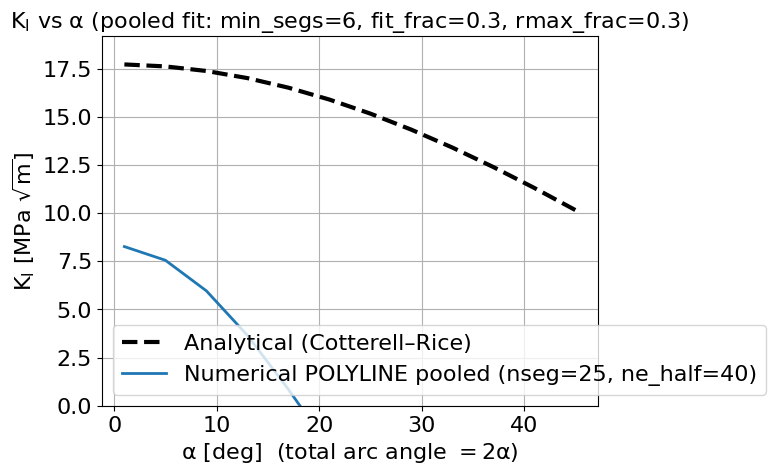

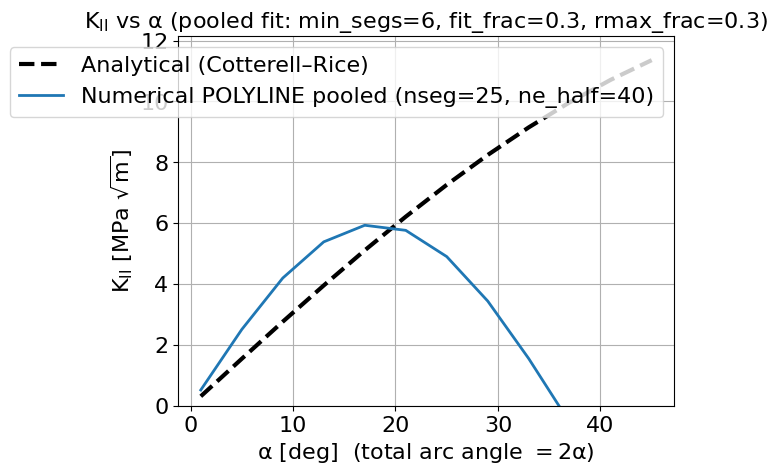

In [9]:
# ============================================================
# Cotterell–Rice validation for circular arc crack using a POLYLINE approximation
# FIT OVER MULTIPLE TIP-NEAR SEGMENTS (module-based pooled Euclid fit)
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *
out_dir = Path(repo_root) / "output" / "ArcPolyline_CotterellRice_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Inputs
# -------------------------
mm = 1e-3
a_chord = 10.0 * mm
E = 200e9
nu = 0.30
plane = "stress"   # or "strain"

sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

alpha_deg = np.linspace(1.0, 45.0, 12)
alpha = np.deg2rad(alpha_deg)

ne_half = 40
nseg_test = 25
scale = 1e-6

# pooled-fit controls (for titles + passing into solve)
min_segs = 6
fit_frac = 0.30      # fraction of total polyline arclength pooled (module semantics)
rmax_frac = 0.30     # rmax = rmax_frac * a_arc
two_term = True

base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)

# -------------------------
# Use module pooled polyline SIF
# -------------------------
from fracture_utils.Uprocessor import SIF_cod as sifcod

def solve_arc_polyline(al, *, ne_half, nseg, fit_frac, min_segs, rmax_frac, two_term):
    """
    Returns:
      a_arc (half arc length),
      KI_CR, KII_CR (in CR comparison frame),
      meta (dict)
    """
    # geometry / reference length for Cotterell–Rice
    R = a_chord / np.sin(al)
    a_arc = R * al  # HALF arc length (CR uses this)

    # build polyline network
    net, V = polyline_arc_network(al, a_chord, nseg=nseg)

    # last segment is the physical right tip segment
    edge_tip = int(nseg - 1)

    KI, KII, KI_CR, KII_CR, meta = sifcod.solve_K_polyline(
        net=net,
        V=V,
        ne_half=int(ne_half),
        edge_index_use=edge_tip,
        a_fit_global=float(a_arc),
        E=E, nu=nu, plane=plane,
        sig_xx=sig_xx, sig_yy=sig_yy, sig_xy=sig_xy,
        base_knobs=base_knobs,

        # pooled-window controls (module)
        fit_frac=float(fit_frac),
        min_segs=int(min_segs),
        rmin_frac=1e-6,
        rmax_frac=float(rmax_frac),
        min_pts=12,
        two_term=bool(two_term),

        # rotate to CR frame
        theta_rot_override=float(-2.0 * al),
    )

    return float(a_arc), float(KI_CR), float(KII_CR), meta

# -------------------------
# Run sweep
# -------------------------
KI_ana, KII_ana = [], []
KI_poly, KII_poly = [], []
meta_list = []

for al in alpha:
    # analytical (must use a_arc = R*al)
    R = a_chord / np.sin(al)
    a_arc = R * al
    KIa, KIIa = cotterell_rice_K(al, a_arc, sig_xx, sig_yy, sig_xy)
    KI_ana.append(KIa)
    KII_ana.append(KIIa)

    # numerical pooled polyline fit (module)
    a_used, KIn, KIIn, meta = solve_arc_polyline(
        al,
        ne_half=ne_half,
        nseg=nseg_test,
        fit_frac=fit_frac,
        min_segs=min_segs,
        rmax_frac=rmax_frac,
        two_term=two_term,
    )
    KI_poly.append(KIn)
    KII_poly.append(KIIn)
    meta_list.append(meta)

KI_ana  = np.asarray(KI_ana, float)
KII_ana = np.asarray(KII_ana, float)
KI_poly = np.asarray(KI_poly, float)
KII_poly = np.asarray(KII_poly, float)

# If your historical convention requires flipping KII, do it here (otherwise comment out)
KII_poly = -KII_poly

print("Example meta (last alpha):", meta_list[-1])

# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots()
ax1.plot(alpha_deg, KI_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax1.plot(alpha_deg, KI_poly*scale, lw=2, label=f"Numerical POLYLINE pooled (nseg={nseg_test}, ne_half={ne_half})")
ax1.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax1.set_ylabel(r"$K_I$ [MPa $\sqrt{m}$]")
ax1.set_title(rf"$K_I$ vs $\alpha$ (pooled fit: min_segs={min_segs}, fit_frac={fit_frac}, rmax_frac={rmax_frac})")
ax1.grid(True); ax1.legend()
ax1.set_ylim(bottom=0)
fig1.savefig(out_dir / f"K_I_vs_alpha_polyline_pooled_ne{ne_half}_nseg{nseg_test}.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots()
ax2.plot(alpha_deg, KII_ana*scale, "k--", lw=3, label="Analytical (Cotterell–Rice)")
ax2.plot(alpha_deg, KII_poly*scale, lw=2, label=f"Numerical POLYLINE pooled (nseg={nseg_test}, ne_half={ne_half})")
ax2.set_xlabel(r"$\alpha$ [deg]  (total arc angle $=2\alpha$)")
ax2.set_ylabel(r"$K_{II}$ [MPa $\sqrt{m}$]")
ax2.set_title(rf"$K_{{II}}$ vs $\alpha$ (pooled fit: min_segs={min_segs}, fit_frac={fit_frac}, rmax_frac={rmax_frac})")
ax2.grid(True); ax2.legend()
ax2.set_ylim(bottom=0)
fig2.savefig(out_dir / f"K_II_vs_alpha_polyline_pooled_ne{ne_half}_nseg{nseg_test}.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
# ============================================================
# Diagnostics: L2 error vs ne_half and vs rmax_frac
# ============================================================

def compute_K_arrays(ne_half_val, rmax_frac_val, *, fit_frac, min_segs, two_term):
    KI_ana, KII_ana = [], []
    KI_num, KII_num = [], []

    for al in alpha:
        R = a_chord / np.sin(al)
        a_fit_global = R * al  # half arc length

        KIa, KIIa = cotterell_rice_K(al, a_fit_global, sig_xx, sig_yy, sig_xy)
        KI_ana.append(KIa); KII_ana.append(KIIa)

        net, V = polyline_arc_network(al, a_chord, nseg=nseg_test)

        KI_loc, KII_loc, KI_CR, KII_CR, meta = solve_K_polyline(
            net, V, int(ne_half_val), edge_tip, a_fit_global,
            E=E, nu=nu, plane=plane,
            sig_xx=sig_xx, sig_yy=sig_yy, sig_xy=sig_xy,
            base_knobs=base_knobs,
            fit_frac=float(fit_frac),
            min_segs=int(min_segs),
            rmax_frac=float(rmax_frac_val),
            two_term=bool(two_term),
        )

        # keep your convention (KII positive)
        if KII_CR < 0.0:
            KII_CR = -KII_CR

        KI_num.append(KI_CR)
        KII_num.append(KII_CR)

    KI_ana = np.asarray(KI_ana, float)
    KII_ana = np.asarray(KII_ana, float)
    KI_num = np.asarray(KI_num, float)
    KII_num = np.asarray(KII_num, float)
    return KI_ana, KII_ana, KI_num, KII_num


def rel_L2(num, ana):
    num = np.asarray(num, float)
    ana = np.asarray(ana, float)
    denom = np.linalg.norm(ana)
    if denom == 0:
        return np.nan
    return np.linalg.norm(num - ana) / denom


# -------------------------
# (1) L2 error vs ne_half
# -------------------------
ne_list = np.arange(30, 61, 2)  # 2..40 in steps of 2 (change if you want every integer)
errKI_ne = []
errKII_ne = []

# Use the SAME knobs you currently used in the main loop
fit_frac_fixed = 0.3
min_segs_fixed = 4
rmax_fixed = 0.1
two_term_fixed = False

for ne_val in ne_list:
    KIa, KIIa, KIn, KIIn = compute_K_arrays(
        ne_val, rmax_fixed,
        fit_frac=fit_frac_fixed,
        min_segs=min_segs_fixed,
        two_term=two_term_fixed
    )
    errKI_ne.append(rel_L2(KIn, KIa))
    errKII_ne.append(rel_L2(KIIn, KIIa))

errKI_ne = np.asarray(errKI_ne, float)
errKII_ne = np.asarray(errKII_ne, float)

fig, ax = plt.subplots()
ax.plot(ne_list, errKI_ne, "o-", label=r"$\epsilon_{K_I}$ (rel. L2)")
ax.plot(ne_list, errKII_ne, "s-", label=r"$\epsilon_{K_{II}}$ (rel. L2)")
ax.set_xlabel(r"$n_e$ (ne\_half)")
ax.set_ylabel("Relative L2 error")
ax.set_title(f"L2 error vs ne_half  (nseg={nseg_test}, rmax_frac={rmax_fixed})")
ax.grid(True)
ax.legend()
fig.savefig(out_dir / f"L2_error_vs_ne_half_nseg{nseg_test}_rmax{rmax_fixed}.png", dpi=300, bbox_inches="tight")
plt.show()



NameError: name 'edge_tip' is not defined

In [ ]:

# -------------------------
# (2) L2 error vs rmax_frac
# -------------------------
rmax_list = np.linspace(0.05, 0.20, 20)
errKI_r = []
errKII_r = []

ne_fixed = 40  # per your request

for rmax_val in rmax_list:
    KIa, KIIa, KIn, KIIn = compute_K_arrays(
        ne_fixed, rmax_val,
        fit_frac=fit_frac_fixed,
        min_segs=min_segs_fixed,
        two_term=two_term_fixed
    )
    errKI_r.append(rel_L2(KIn, KIa))
    errKII_r.append(rel_L2(KIIn, KIIa))

errKI_r = np.asarray(errKI_r, float)
errKII_r = np.asarray(errKII_r, float)

fig, ax = plt.subplots()
ax.plot(rmax_list, errKI_r, "o-", label=r"$\epsilon_{K_I}$ (rel. L2)")
ax.plot(rmax_list, errKII_r, "s-", label=r"$\epsilon_{K_{II}}$ (rel. L2)")
ax.set_xlabel(r"$r_{\max,\mathrm{frac}}$")
ax.set_ylabel("Relative L2 error")
ax.set_title(f"L2 error vs rmax_frac  (nseg={nseg_test}, ne_half={ne_fixed})")
ax.grid(True)
ax.legend()
fig.savefig(out_dir / f"L2_error_vs_rmax_nseg{nseg_test}_ne{ne_fixed}.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
## STRAIGHT CRACK VALIDATION: Lo Journal of Applied Mechanics 1978, vol 45-p797
# ============================================================
## (1) Single Straight Crack
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# --- Preamble re-exports
from preamble import *   

out_dir = Path(repo_root) / "output" / "Straight_Crack_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
c = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]) * mm

# Material and loading
E = 200e9
nu = 0.30
plane = "strain"
sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

# Solver parameters
ne_half = 100
base_knobs = dict(
    crack_mode="half",
    representation="cheb_quad",
    node_distribution="tip_dense",
    nq_col=12,
    nq_stress=16,
    ridge=1e-10,
    r0_factor=1e-3,
    solver_option="parametrized_crack",
    junction_model="strict",
    parametrization="polyline",
)

# ----------------------------
# Build straight crack network
# ----------------------------
def build_straight_crack(crack_half_length):
    """
    Build straight crack centered at origin
    
    Parameters
    ----------
    crack_half_length : float
        Half-length of crack (c)
    
    Returns
    -------
    net : CrackNetworkV4
        Crack network
    vertices : ndarray
        Vertex array
    """
    vertices = np.array([
        [0,  -crack_half_length,  0.0],  # v0 (left tip)
        [1,   crack_half_length,  0.0],  # v1 (right tip)
    ], dtype=float)
    
    connectivity = np.array([
        [0, 1],   # e0: main crack
    ], dtype=int)
    
    net = CrackNetworkV4.from_vertices_connectivity(
        vertices=vertices,
        connectivity=connectivity,
        Nv_max=2,
        validate=True
    )
    
    return net, vertices

# ----------------------------
# Run sweep over crack lengths
# ----------------------------
KI_right = []
KII_right = []
KI_left = []
KII_left = []

material = Material(E=E, nu=nu, plane_stress=False)
applied = AppliedStress(sigma_xx=sig_xx, sigma_yy=sig_yy, sigma_xy=sig_xy)

# Extract material properties
mu = material.mu
kappa = material.kappa

print(f"Material properties:")
print(f"  E = {E/1e9:.1f} GPa")
print(f"  nu = {nu}")
print(f"  mu = {mu/1e9:.2f} GPa")
print(f"  kappa = {kappa:.2f}")
print()

for length in c:    
    print(f"Solving for c = {length*1e3:.2f} mm...")
    
    # Build network
    net, vertices = build_straight_crack(length)
    
    # Solve
    calc = DCENetworkStaticV4(material, net, applied)
    knobs = dict(base_knobs)
    knobs["ne_half"] = ne_half
    
    sol = calc.solve(**knobs)
    res = DCEResultsNetworkV4(calc, sol)
    
    # Extract COD/CSD for the crack edge
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=0,
        enforce_global_tip_zero=True,
    )
    
    # Extract SIFs for right tip (tip="right" means measuring from right end)
    try:
        KI_r, KII_r, meta_r = sif_from_cod_fit(
            x=x,
            COD=COD,
            CSD=CSD,
            a=length,           # crack half-length
            mu=mu,              # shear modulus from material
            kappa=kappa,        # Kolosov constant from material
            tip="right",        # measuring from right tip
            window="auto",
            rho_min=1e-3,
            rho_max=0.05,
            n_fit=80,
            two_term=False,
        )
        KI_right.append(KI_r)
        KII_right.append(abs(KII_r))
    except Exception as e:
        print(f"  Warning: Right tip fit failed: {e}")
        KI_right.append(np.nan)
        KII_right.append(np.nan)

    # Extract SIFs for left tip (tip="left" means measuring from left end)
    try:
        KI_l, KII_l, meta_l = sif_from_cod_fit(
            x=x,
            COD=COD,
            CSD=CSD,
            a=length,           # crack half-length
            mu=mu,
            kappa=kappa,
            tip="left",         # measuring from left tip
            window="auto",
            rho_min=1e-3,
            rho_max=0.05,
            n_fit=80,
            two_term=False,
        )
        KI_left.append(KI_l)
        KII_left.append(abs(KII_l))
    except Exception as e:
        print(f"  Warning: Left tip fit failed: {e}")
        KI_left.append(np.nan)
        KII_left.append(np.nan)

# Convert to arrays
KI_right = np.array(KI_right)
KII_right = np.array(KII_right)
KI_left = np.array(KI_left)
KII_left = np.array(KII_left)

# Average left and right (should be symmetric)
KI_avg = (KI_right + KI_left) / 2.0
KII_avg = (KII_right + KII_left) / 2.0

# Analytical solution for straight crack under remote tension
K_analytical = sig_yy * np.sqrt(np.pi * c)

# Calculate percent error
error_KI = 100.0 * (KI_avg - K_analytical) / K_analytical

# -------------------------
# Plots
# -------------------------
scale = 1e-6  # Convert to MPa√m

# Plot 1: K_I comparison (numerical vs analytical)
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(c*1e3, K_analytical*scale, 'k--', lw=3, label='Analytical: $\sigma_\infty\sqrt{\pi c}$')
ax1.plot(c*1e3, KI_avg*scale, 'o-', lw=2, markersize=8, label=f'Numerical (ne_half={ne_half})')
ax1.set_xlabel(r'$c$ [mm] (crack half-length)', fontsize=16)
ax1.set_ylabel(r'$K_I$ [MPa$\sqrt{m}$]', fontsize=16)
ax1.set_title('Straight Crack: $K_I$ vs Crack Size', fontsize=16, weight='bold')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=16)
plt.tight_layout()
fig1.savefig(out_dir / "straight_KI_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Percent error
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.axhline(0.0, color='k', linestyle='--', lw=2, alpha=0.5, label='Zero error')
ax2.plot(c*1e3, error_KI, 'o-', lw=2, markersize=8, color='C1', label=f'Error (ne_half={ne_half})')
ax2.set_xlabel(r'$c$ [mm] (crack half-length)', fontsize=16)
ax2.set_ylabel(r'Error in $K_I$ [%]', fontsize=16)
ax2.set_title('Straight Crack: Percent Error in $K_I$', fontsize=16, weight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=16)
plt.tight_layout()
fig2.savefig(out_dir / "straight_KI_error.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: K_II (should be near zero for Mode I loading)
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(c*1e3, KII_avg*scale, 's-', lw=2, markersize=8, label=f'Numerical (ne_half={ne_half})')
ax3.axhline(0.0, color='k', linestyle='--', lw=1, alpha=0.5, label='Expected: $K_{II} = 0$')
ax3.set_xlabel(r'$c$ [mm] (crack half-length)', fontsize=16)
ax3.set_ylabel(r'$K_{II}$ [MPa$\sqrt{m}$]', fontsize=16)
ax3.set_title('Straight Crack: $K_{II}$ vs Crack Size (should be ≈ 0)', fontsize=16, weight='bold')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=16)
plt.tight_layout()
fig3.savefig(out_dir / "straight_KII.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*70)
print("STRAIGHT CRACK VALIDATION SUMMARY")
print("="*70)
print(f"{'c [mm]':<12} {'K_I Analytical':<18} {'K_I Numerical':<18} {'Error [%]':<12}")
print("-"*70)
for i, length in enumerate(c):
    print(f"{length*1e3:<12.2f} {K_analytical[i]*scale:<18.4f} {KI_avg[i]*scale:<18.4f} {error_KI[i]:<12.2f}")
print("="*70)

print("\n" + "="*60)
print("Straight crack validation complete!")
print(f"Results saved to: {out_dir}")
print("="*60)

In [ ]:
## BRANCHED CRACK VALIDATION: Lo J. Applied Mechanics (1978) 45, p797
# ============================================================
# Symmetric Branched Crack (robust Euclidean near-tip fit)
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

out_dir = Path(repo_root) / "output" / "Branched_Crack_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
c = 1000.0 * mm
# c_over_l = np.linspace(1, 201, 10, dtype=float)
c_over_l = np.array([1,2,3,4,5,6,7,8,9,10,15,20,30,40,50, 75, 100, 200], float)
theta_deg = 15.0
theta = np.deg2rad(theta_deg)

# Material and loading
E = 200e9
nu = 0.30
plane = "strain"
sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

def print_meta(label, ratio, meta, l):
    print(
        f"[{label}] c/l={ratio:g} | "
        f"keys={list(meta.keys())} | "
        f"rr_size={meta.get('rr_size', 'NA')} | "
        f"rmax/l={meta.get('rmax', np.nan)/l if 'rmax' in meta else np.nan:.3f}"
    )

# ----------------------------
# Build a symmetric branched crack network
# ----------------------------
def build_branched_crack(c, l, theta):
    vertices = np.array([
        [0,  -c,  0.0],
        [1,   c,  0.0],
        [2,   c + l*np.cos(theta),   l*np.sin(theta)],
        [3,   c + l*np.cos(theta),  -l*np.sin(theta)],
    ], dtype=float)

    connectivity = np.array([
        [0, 1],   # e0 main
        [1, 2],   # e1 top branch
        [1, 3],   # e2 bottom branch
    ], dtype=int)

    net = CrackNetworkV4.from_vertices_connectivity(
        vertices=vertices,
        connectivity=connectivity,
        Nv_max=4,
        validate=True
    )
    return net, vertices

# ----------------------------
# Run sweep over c/l ratios
# ----------------------------
KI_top, KII_top = [], []
KI_bot, KII_bot = [], []
KI_main, KII_main = [], []

material = Material(E=E, nu=nu, plane_stress=False)
applied = AppliedStress(sigma_xx=sig_xx, sigma_yy=sig_yy, sigma_xy=sig_xy)

mu = float(material.mu)

# Euclid-fit controls (robust defaults)
rmax_frac_branch = 0.05   # branches can be short => allow a bit wider
rmax_frac_main   = 0.05
min_pts = 4
two_term = True
ne_half = 40

for ratio in c_over_l:
    l = c / ratio

    print(f"Solving for c/l = {ratio:g} (l = {l*1e3:.3f} mm)...")

    net, vertices = build_branched_crack(c, l, theta)

    calc = DCENetworkStaticV4(material, net, applied)
    
    sol = calc.solve(
        ne_half=ne_half,
        crack_mode="half",
        representation="cheb_quad",
        node_distribution="uniform",      # recommended for non-tip segments in this strategy
        nq_col=12,
        nq_stress=16,
        solver_option="parametrized_crack",
        parametrization="polyline",
        junction_model="strict",

        # NEW (tip refinement)
        tip_min_nodes=6,                 # enforce >=6 nodes on each tip segment
        tip_cluster="power",              # "power" (one-sided) or "cheb" (symmetric)
        tip_cluster_power=3.0,            # stronger clustering as p increases (>=2)
        other_min_panels=4,               # baseline per segment
        endpoint_min_nodes=6,        # new
        kink_side_nodes=3,           # new
        refine_junction_endpoints=True,
        refine_kinks=True,
        )
    res = DCEResultsNetworkV4(calc, sol)

    # tip coordinates (global)
    p_top  = vertices[2, 1:3]
    p_bot  = vertices[3, 1:3]
    p_left = vertices[0, 1:3]

    # --- Top branch tip (edge 1, tip at v2)
    try:
        KI_t, KII_t, KI_t_CR, KII_t_CR, meta_t = euclid_tip_fit_from_edge(
            res, edge_index=1, tip_xy=p_top,
            a_fit=l, rmax_frac=rmax_frac_branch, min_pts=min_pts, two_term=two_term, theta=theta,
            material=material
        )
        
        KI_top.append(KI_t)
        KII_top.append(KII_t)
    except Exception as e:
        print(f"  Warning: Top branch fit failed: {e}")
        KI_top.append(np.nan); KII_top.append(np.nan)
    
    # --- Bottom branch tip (edge 2, tip at v3)
    try:
        KI_b, KII_b, KI_b_CR, KII_b_CR, meta_b = euclid_tip_fit_from_edge(
            res, edge_index=2, tip_xy=p_bot,
            a_fit=l, rmax_frac=rmax_frac_branch, min_pts=min_pts, two_term=two_term, theta=-theta,
            material=material
        )
        KI_bot.append(KI_b)
        KII_bot.append(KII_b)
    except Exception as e:
        print(f"  Warning: Bottom branch fit failed: {e}")
        KI_bot.append(np.nan); KII_bot.append(np.nan)

    # --- Main crack left tip (edge 0, tip at v0)
    try:
        KI_m, KII_m, KI_m_CR, KII_m_CR, meta_m = euclid_tip_fit_from_edge(
            res, edge_index=0, tip_xy=p_left,
            a_fit=c,
            rmax_frac=rmax_frac_main, min_pts=min_pts, two_term=two_term, theta=0.0,
            material=material
        )
        KI_main.append(KI_m)
        KII_main.append(KII_m)
    except Exception as e:
        print(f"  Warning: Main crack fit failed: {e}")
        KI_main.append(np.nan); KII_main.append(np.nan)
        
# Convert to arrays
KI_top = np.array(KI_top);   KII_top = np.array(KII_top)
KI_bot = np.array(KI_bot);   KII_bot = np.array(KII_bot)
KI_main = np.array(KI_main); KII_main = np.array(KII_main)

# Normalize by reference SIF
K_ref = sig_yy * np.sqrt(np.pi * c)
KI_branch_norm = KI_top / K_ref
KII_branch_norm = KII_top / K_ref
KI_main_norm = KI_main / K_ref
KII_main_norm = KII_main / K_ref

# -------------------------
# Lo (JAM 1978) digitized data (branch SIFs)
# -------------------------
lo_KI = np.array([
    [0.977157764, 0.888603531],
    [1.22156035 , 0.858908507],
    [1.754476973, 0.820385233],
    [2.494862119, 0.792295345],
    [4.855432594, 0.755377207],
    [8.929324781, 0.736918138],
    [20.46800156, 0.728892456],
    [60.6877622 , 0.728089888],
    [178.2899264, 0.727287319],
], float)

lo_KII = np.array([
    [0.995465377, 0.093361835],
    [1.306903865, 0.076523857],
    [1.683851068, 0.061291159],
    [2.450969943, 0.040453082],
    [3.918340794, 0.017222372],
    [6.626457855, -0.005190409],
    [10.20229795, -0.021991258],
    [31.44051859, -0.053922155],
    [84.94829929, -0.07220161],
], float)

lo_cl_KI,  lo_KI_norm  = lo_KI[:,0],  lo_KI[:,1]
lo_cl_KII, lo_KII_norm = lo_KII[:,0], lo_KII[:,1]

def interp_logx(xq, x, y):
    """
    Interpolate y(x) onto query points xq using linear interpolation in log10(x).
    Assumes x > 0 and sorted ascending.
    """
    xq = np.asarray(xq, float)
    x  = np.asarray(x, float)
    y  = np.asarray(y, float)

    m = (xq > 0) & (xq >= x.min()) & (xq <= x.max())
    yq = np.full_like(xq, np.nan, dtype=float)
    yq[m] = np.interp(np.log10(xq[m]), np.log10(x), y)
    return yq

loKI_on_grid  = interp_logx(c_over_l, lo_cl_KI,  lo_KI_norm)
loKII_on_grid = interp_logx(c_over_l, lo_cl_KII, lo_KII_norm)

# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots(figsize=(10, 6))
# Numerical (solid line, no symbols)
ax1.plot(c_over_l, KI_branch_norm, '-', lw=2.5, label=f'VCM (branch, ne_half={ne_half})')
# Lo overlay: blue circle edge, red fill, no line
ax1.plot(
    lo_cl_KI, lo_KI_norm,
    linestyle='None',
    marker='o', markersize=7,
    markerfacecolor='red',
    markeredgecolor='blue',
    markeredgewidth=1.5,
    label="Lo (JAM 1978)"
)
ax1.set_xlabel(r'$c/l$', fontsize=16)
ax1.set_ylabel(r'$K_I / (\sigma_\infty \sqrt{\pi c})$', fontsize=16)
ax1.set_title(f'Branch tip: Normalized $K_I$ (θ={theta_deg}°)', fontsize=16, weight='bold')
ax1.set_ylim(bottom=0.0)  # <-- start y-axis at 0 for KI
ax1.grid(True, alpha=0.3)
ax1.legend()

plt.tight_layout()
fig1.savefig(out_dir / "branched_KI_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(c_over_l, KII_branch_norm, '-', lw=2.5, label=f'VCM (branch, ne_half={ne_half})')
ax2.plot(
    lo_cl_KII, lo_KII_norm,
    linestyle='None',
    marker='o', markersize=7,
    markerfacecolor='red',
    markeredgecolor='blue',
    markeredgewidth=1.5,
    label="Lo (JAM 1978)"
)
ax2.set_xlabel(r'$c/l$', fontsize=16)
ax2.set_ylabel(r'$K_{II} / (\sigma_\infty \sqrt{\pi c})$', fontsize=16)
ax2.set_title(f'Branch tip: Normalized $K_{{II}}$ (θ={theta_deg}°)', fontsize=16, weight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
fig2.savefig(out_dir / "branched_KII_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()


fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(c_over_l, KI_main_norm, 'o-', lw=2, markersize=7, label=f'Main crack left tip (ne_half={ne_half})')
ax3.axhline(1.0, color='k', linestyle='--', lw=2, alpha=0.5, label='Unbranched crack: 1.0')
ax3.set_xlabel(r'$c/l$', fontsize=16)
ax3.set_ylabel(r'$K_I / (\sigma_\infty \sqrt{\pi c})$', fontsize=16)
ax3.set_title(f'Main Crack: Normalized $K_I$ vs $c/l$ (θ={theta_deg}°)', fontsize=16, weight='bold')
ax3.set_xscale('linear'); ax3.grid(True, alpha=0.3); ax3.legend()
plt.tight_layout()
fig3.savefig(out_dir / "main_crack_KI_normalized_lin.png", dpi=150, bbox_inches='tight')
plt.show()

err_KI_pct  = 100.0 * (KI_branch_norm  - loKI_on_grid)  / loKI_on_grid
err_KII_pct = 100.0 * (KII_branch_norm - loKII_on_grid) / loKII_on_grid

# Optional: mask where Lo isn't defined over your c/l range
mKI  = np.isfinite(err_KI_pct)
mKII = np.isfinite(err_KII_pct)

fige4, axe1 = plt.subplots(figsize=(10, 5))
axe1.plot(c_over_l[mKI], err_KI_pct[mKI], '-', lw=2.5)
axe1.axhline(0.0, color='k', lw=1, alpha=0.5)
axe1.set_xlabel(r'$c/l$', fontsize=16)
axe1.set_ylabel(r'$\%$ error in $K_I$', fontsize=16)
axe1.set_title(r'Branch tip: $\%$ error vs Lo (JAM 1978) — $K_I$', fontsize=16, weight='bold')
axe1.grid(True, alpha=0.3)
plt.tight_layout()
fige4.savefig(out_dir / "branched_KI_percent_error_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()

fige5, axe2 = plt.subplots(figsize=(10, 5))
axe2.plot(c_over_l[mKII], err_KII_pct[mKII], '-', lw=2.5)
axe2.axhline(0.0, color='k', lw=1, alpha=0.5)
axe2.set_xlabel(r'$c/l$', fontsize=16)
axe2.set_ylabel(r'$\%$ error in $K_{II}$', fontsize=16)
axe2.set_title(r'Branch tip: $\%$ error vs Lo (JAM 1978) — $K_{II}$', fontsize=16, weight='bold')
axe2.grid(True, alpha=0.3)
plt.tight_layout()
fige5.savefig(out_dir / "branched_KII_percent_error_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()


print("\n" + "="*60)
print("Branched crack validation complete!")
print(f"Results saved to: {out_dir}")
print("="*60)


In [ ]:
## BRANCHED CRACK VALIDATION: Lo J. Applied Mechanics (1978) 45, p797
# ============================================================
# Asymmetric Branched Crack (robust Euclidean near-tip fit)
# ============================================================

import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add repo root (one level above notebooks/) to sys.path
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preamble import *

out_dir = Path(repo_root) / "output" / "Branched_Crack_Validation"
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
c = 1000.0 * mm
# c_over_l = np.linspace(1, 201, 10, dtype=float)
# c_over_l = np.array([1,2,3,4,5,6,7,8,9,10,15,20,30,40,50, 75, 100, 200], float)
c_over_l = np.array([1,2,5,10, 20, 50, 100], float)
theta_deg = 15.0
theta = np.deg2rad(theta_deg)

# Material and loading
E = 200e9
nu = 0.30
plane = "strain"
sig_xx = 0e6
sig_yy = 100e6
sig_xy = 0.0

def print_meta(label, ratio, meta, l):
    print(
        f"[{label}] c/l={ratio:g} | "
        f"keys={list(meta.keys())} | "
        f"rr_size={meta.get('rr_size', 'NA')} | "
        f"rmax/l={meta.get('rmax', np.nan)/l if 'rmax' in meta else np.nan:.3f}"
    )

# ----------------------------
# Build a symmetric branched crack network
# ----------------------------
def build_branched_crack(c, l, theta):
    vertices = np.array([
        [0,  -2*c,  0.0],
        [1,   0.0,  0.0],
        [2,   l*np.cos(theta),   l*np.sin(theta)],
    ], dtype=float)

    connectivity = np.array([
        [0, 1],   # e0 main
        [1, 2],   # e1 top branch
    ], dtype=int)

    net = CrackNetworkV4.from_vertices_connectivity(
        vertices=vertices,
        connectivity=connectivity,
        Nv_max=4,
        validate=True
    )
    return net, vertices

# ----------------------------
# Run sweep over c/l ratios
# ----------------------------
KI_top, KII_top = [], []
KI_bot, KII_bot = [], []
KI_main, KII_main = [], []

material = Material(E=E, nu=nu, plane_stress=False)
applied = AppliedStress(sigma_xx=sig_xx, sigma_yy=sig_yy, sigma_xy=sig_xy)

mu = float(material.mu)

# Euclid-fit controls (robust defaults)
rmax_frac_branch = 0.1   # branches can be short => allow a bit wider
rmax_frac_main   = 0.1
min_pts = 8
two_term = False
ne_half = 60

for ratio in c_over_l:
    l = c / ratio

    print(f"Solving for c/l = {ratio:g} (l = {l*1e3:.3f} mm)...")

    net, vertices = build_branched_crack(c, l, theta)

    calc = DCENetworkStaticV4(material, net, applied)
    
    sol = calc.solve(
        ne_half=ne_half,
        crack_mode="full",
        representation="cheb_quad",
        node_distribution="tip_dense",      # recommended for non-tip segments in this strategy
        nq_col=12,
        nq_stress=16,
        solver_option="parametrized_crack",
        parametrization="polyline",
        junction_model="strict",

        # NEW (tip refinement)
        tip_min_nodes=6,                 # enforce >=6 nodes on each tip segment
        tip_cluster="power",              # "power" (one-sided) or "cheb" (symmetric)
        tip_cluster_power=3.0,            # stronger clustering as p increases (>=2)
        other_min_panels=4,               # baseline per segment
        endpoint_min_nodes=6,        # new
        kink_side_nodes=3,           # new
        refine_junction_endpoints=True,
        refine_kinks=True,
        )
    res = DCEResultsNetworkV4(calc, sol)

    # tip coordinates (global)
    p_top  = vertices[2, 1:3]
    p_left = vertices[0, 1:3]

    # --- Top branch tip (edge 1, tip at v2)
    try:
        KI_t, KII_t, KI_t_CR, KII_t_CR, meta_t = euclid_tip_fit_from_edge(
            res, edge_index=1, tip_xy=p_top,
            a_fit=l, rmax_frac=rmax_frac_branch, min_pts=min_pts, two_term=two_term, theta=theta,
            material=material
        )
        
        KI_top.append(KI_t_CR)
        KII_top.append(KII_t_CR)
    except Exception as e:
        print(f"  Warning: Top branch fit failed: {e}")
        KI_top.append(np.nan); KII_top.append(np.nan)


    # --- Main crack left tip (edge 0, tip at v0)
    try:
        KI_m, KII_m, KI_m_CR, KII_m_CR, meta_m = euclid_tip_fit_from_edge(
            res, edge_index=0, tip_xy=p_left,
            a_fit=c,
            rmax_frac=rmax_frac_main, min_pts=min_pts, two_term=two_term, theta=.0,
            material=material
        )
        KI_main.append(KI_m)
        KII_main.append(KII_m)
    except Exception as e:
        print(f"  Warning: Main crack fit failed: {e}")
        KI_main.append(np.nan); KII_main.append(np.nan)
        
# Convert to arrays
KI_top = np.array(KI_top);   KII_top = np.array(KII_top)
KI_main = np.array(KI_main); KII_main = np.array(KII_main)

# Normalize by reference SIF
K_ref = sig_yy * np.sqrt(np.pi * c)
KI_branch_norm = KI_top / K_ref
KII_branch_norm = KII_top / K_ref
KI_main_norm = KI_main / K_ref
KII_main_norm = KII_main / K_ref

# -------------------------
# Lo (JAM 1978) digitized data (branch SIFs)
# -------------------------
lo_KI = np.array([
    [0.976147056,	1.152648475],
    [1.143765727,	1.126966292],
    [1.378120901,	1.097271268],
    [1.89014178,	1.059550562],
    [2.450847066,	1.033868379],
    [3.326275879,	1.013804173],
    [4.903693017,	0.996147673],
    [7.565839828,	0.985714286],
    [12.56285313,	0.978491172],
    [44.80162225,	0.972070626],
    # [285.3622159,	0.968860353],
], float)

lo_KII = np.array([
    [0.990222752,	0.318712717],
    [1.36272909,	0.29142294],
    [2.002533967,	0.26414845],
    [3.26237831,	0.236093161],
    [5.782060166,	0.212081651],
    [13.3241222,	0.184911996],
    [33.4000804,	0.165810244],
    [127.6576459,	0.145197125],
    # [329.0243998,	0.139783942],
    # [976.0579,	    0.133598696],
], float)

lo_cl_KI,  lo_KI_norm  = lo_KI[:,0],  lo_KI[:,1]
lo_cl_KII, lo_KII_norm = lo_KII[:,0], lo_KII[:,1]

def interp_logx(xq, x, y):
    """
    Interpolate y(x) onto query points xq using linear interpolation in log10(x).
    Assumes x > 0 and sorted ascending.
    """
    xq = np.asarray(xq, float)
    x  = np.asarray(x, float)
    y  = np.asarray(y, float)

    m = (xq > 0) & (xq >= x.min()) & (xq <= x.max())
    yq = np.full_like(xq, np.nan, dtype=float)
    yq[m] = np.interp(np.log10(xq[m]), np.log10(x), y)
    return yq

loKI_on_grid  = interp_logx(c_over_l, lo_cl_KI,  lo_KI_norm)
loKII_on_grid = interp_logx(c_over_l, lo_cl_KII, lo_KII_norm)

# -------------------------
# Plots
# -------------------------
fig1, ax1 = plt.subplots(figsize=(10, 6))
# Numerical (solid line, no symbols)
ax1.plot(c_over_l, KI_branch_norm, '-', lw=2.5, label=f'VCM (branch, ne_half={ne_half})')
# Lo overlay: blue circle edge, red fill, no line
ax1.plot(
    lo_cl_KI, lo_KI_norm,
    linestyle='None',
    marker='o', markersize=7,
    markerfacecolor='red',
    markeredgecolor='blue',
    markeredgewidth=1.5,
    label="Lo (JAM 1978)"
)
ax1.set_xlabel(r'$c/l$', fontsize=16)
ax1.set_ylabel(r'$K_I / (\sigma_\infty \sqrt{\pi c})$', fontsize=16)
ax1.set_title(f'Branch tip: Normalized $K_I$ (θ={theta_deg}°)', fontsize=16, weight='bold')
ax1.set_ylim(bottom=0.0)  # <-- start y-axis at 0 for KI
ax1.grid(True, alpha=0.3)
ax1.legend()

plt.tight_layout()
fig1.savefig(out_dir / "branched_KI_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(c_over_l, KII_branch_norm, '-', lw=2.5, label=f'VCM (branch, ne_half={ne_half})')
ax2.plot(
    lo_cl_KII, lo_KII_norm,
    linestyle='None',
    marker='o', markersize=7,
    markerfacecolor='red',
    markeredgecolor='blue',
    markeredgewidth=1.5,
    label="Lo (JAM 1978)"
)
ax2.set_xlabel(r'$c/l$', fontsize=16)
ax2.set_ylabel(r'$K_{II} / (\sigma_\infty \sqrt{\pi c})$', fontsize=16)
ax2.set_title(f'Branch tip: Normalized $K_{{II}}$ (θ={theta_deg}°)', fontsize=16, weight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
fig2.savefig(out_dir / "branched_KII_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()


fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(c_over_l, KI_main_norm, 'o-', lw=2, markersize=7, label=f'Main crack left tip (ne_half={ne_half})')
ax3.axhline(1.0, color='k', linestyle='--', lw=2, alpha=0.5, label='Unbranched crack: 1.0')
ax3.set_xlabel(r'$c/l$', fontsize=16)
ax3.set_ylabel(r'$K_I / (\sigma_\infty \sqrt{\pi c})$', fontsize=16)
ax3.set_title(f'Main Crack: Normalized $K_I$ vs $c/l$ (θ={theta_deg}°)', fontsize=16, weight='bold')
ax3.set_xscale('linear'); ax3.grid(True, alpha=0.3); ax3.legend()
plt.tight_layout()
fig3.savefig(out_dir / "main_crack_KI_normalized_lin.png", dpi=150, bbox_inches='tight')
plt.show()

err_KI_pct  = 100.0 * (KI_branch_norm  - loKI_on_grid)  / loKI_on_grid
err_KII_pct = 100.0 * (KII_branch_norm - loKII_on_grid) / loKII_on_grid

# Optional: mask where Lo isn't defined over your c/l range
mKI  = np.isfinite(err_KI_pct)
mKII = np.isfinite(err_KII_pct)

fige4, axe1 = plt.subplots(figsize=(10, 5))
axe1.plot(c_over_l[mKI], err_KI_pct[mKI], '-', lw=2.5)
axe1.axhline(0.0, color='k', lw=1, alpha=0.5)
axe1.set_xlabel(r'$c/l$', fontsize=16)
axe1.set_ylabel(r'$\%$ error in $K_I$', fontsize=16)
axe1.set_title(r'Branch tip: $\%$ error vs Lo (JAM 1978) — $K_I$', fontsize=16, weight='bold')
axe1.grid(True, alpha=0.3)
plt.tight_layout()
fige4.savefig(out_dir / "branched_KI_percent_error_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()

fige5, axe2 = plt.subplots(figsize=(10, 5))
axe2.plot(c_over_l[mKII], err_KII_pct[mKII], '-', lw=2.5)
axe2.axhline(0.0, color='k', lw=1, alpha=0.5)
axe2.set_xlabel(r'$c/l$', fontsize=16)
axe2.set_ylabel(r'$\%$ error in $K_{II}$', fontsize=16)
axe2.set_title(r'Branch tip: $\%$ error vs Lo (JAM 1978) — $K_{II}$', fontsize=16, weight='bold')
axe2.grid(True, alpha=0.3)
plt.tight_layout()
fige5.savefig(out_dir / "branched_KII_percent_error_vs_Lo.png", dpi=150, bbox_inches='tight')
plt.show()


print("\n" + "="*60)
print("Branched crack validation complete!")
print(f"Results saved to: {out_dir}")
print("="*60)
